<a href="https://colab.research.google.com/github/selim679/Emotion_detection/blob/main/emotion_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers==4.39.0 text_hammer kagglehub


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import text_hammer as th
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, Concatenate, Bidirectional, LSTM, MultiHeadAttention
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import CategoricalAccuracy
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from transformers import AutoTokenizer, TFBertModel

warnings.filterwarnings("ignore")

In [ ]:
SKIP_TRAINING = False # 🔥 Mettez True pour charger le modèle existant

In [ ]:
import kagglehub
path = kagglehub.dataset_download("pashupatigupta/emotion-detection-from-text")

df = pd.read_csv(os.path.join(path, "tweet_emotions.csv"))
df = df.rename(columns={"content": "text", "sentiment": "label"})
df = df[df['label'] != 'empty'].reset_index(drop=True)

# Filtrer pour garder seulement 5 émotions
KEEP_EMOTIONS = ['happiness', 'love', 'neutral', 'sadness', 'worry']
df = df[df['label'].isin(KEEP_EMOTIONS)].reset_index(drop=True)

# 🔥 AMÉLIORATION 1: Équilibrer les classes avec undersampling/oversampling
from sklearn.utils import resample

print("\n📊 Distribution AVANT équilibrage:")
print(df['label'].value_counts())

# Trouver la taille médiane des classes
median_size = df['label'].value_counts().median()
target_size = int(median_size * 1.2)  # Légèrement plus que la médiane

balanced_dfs = []
for emotion in KEEP_EMOTIONS:
    emotion_df = df[df['label'] == emotion]

    if len(emotion_df) > target_size:
        # Sous-échantillonner les classes majoritaires
        emotion_df = resample(emotion_df, n_samples=target_size, random_state=42)
    elif len(emotion_df) < target_size:
        # Sur-échantillonner les classes minoritaires
        emotion_df = resample(emotion_df, n_samples=target_size, replace=True, random_state=42)

    balanced_dfs.append(emotion_df)

df = pd.concat(balanced_dfs, ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # Mélanger

print("\n📊 Distribution APRÈS équilibrage:")
print(df['label'].value_counts())

# Encoder les labels
df['label'] = df['label'].astype('category')
df['label_code'] = df['label'].cat.codes


100%|██████████| 1.56M/1.56M [00:00<00:00, 132MB/s]

Extracting files...

📊 Distribution AVANT équilibrage:
label
neutral      8638
worry        8459
happiness    5209
sadness      5165
love         3842
Name: count, dtype: int64

📊 Distribution APRÈS équilibrage:
label
sadness      6250
worry        6250
love         6250
neutral      6250
happiness    6250
Name: count, dtype: int64


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = th.cont_exp(text)
    text = th.remove_emails(text)
    text = th.remove_html_tags(text)
    text = th.remove_special_chars(text)
    text = th.remove_accented_chars(text)
    return text.strip()

df['text'] = df['text'].apply(clean_text)
df = df[df['text'].str.len() > 3].reset_index(drop=True)

In [ ]:

# ========== SPLIT TRAIN/VAL/TEST ==========
X_train, X_temp, y_train, y_temp = train_test_split(
    df['text'], df['label_code'],
    test_size=0.25, random_state=42, stratify=df['label_code']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nTrain: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Train: 23436, Val: 3906, Test: 3907


In [ ]:
# ========== TOKENIZATION ==========
#MAX_LEN = 128  # Augmenté pour capturer plus de contexte
#tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")  # uncased pour textes nettoyés

#x_train = tokenizer(
#    X_train.tolist(), max_length=MAX_LEN,
#    padding='max_length', truncation=True, return_tensors='tf'
#)
#x_val = tokenizer(
#    X_val.tolist(), max_length=MAX_LEN,
#    padding='max_length', truncation=True, return_tensors='tf'
#)
#x_test = tokenizer(
#    X_test.tolist(), max_length=MAX_LEN,
#    padding='max_length', truncation=True, return_tensors='tf'
#"")


In [ ]:
# 🔥 AMÉLIORATION 2: MAX_LEN plus long pour capturer plus de contexte
MAX_LEN = 150
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

x_train = tokenizer(X_train.tolist(), max_length=MAX_LEN, padding='max_length', truncation=True, return_tensors='tf')
x_val = tokenizer(X_val.tolist(), max_length=MAX_LEN, padding='max_length', truncation=True, return_tensors='tf')
x_test = tokenizer(X_test.tolist(), max_length=MAX_LEN, padding='max_length', truncation=True, return_tensors='tf')

# ========== MODÈLE ULTRA-OPTIMISÉ ==========
def build_ultra_emotion_model(num_classes, max_len=150):
    # 🔥 AMÉLIORATION 3: Charger BERT
    bert = TFBertModel.from_pretrained("bert-base-uncased", from_pt=True)

    # 🔥 AMÉLIORATION 4: Entraîner TOUTES les couches de BERT (pas de gel!)
    bert.trainable = True

    # Ne geler QUE les embeddings pour stabilité
    bert.bert.embeddings.trainable = False

    # Inputs
    input_ids = Input(shape=(max_len,), dtype=tf.int32, name="input_ids")
    attention_mask = Input(shape=(max_len,), dtype=tf.int32, name="attention_mask")

    # Custom BERT layer
    class BertLayer(tf.keras.layers.Layer):
        def __init__(self, bert_model, **kwargs):
            super().__init__(**kwargs)
            self.bert = bert_model

        def call(self, inputs):
            ids, mask = inputs
            outputs = self.bert(ids, attention_mask=mask)
            return outputs[0], outputs[1]

        def get_config(self):
            return super().get_config()

    bert_layer = BertLayer(bert)
    last_hidden, pooled = bert_layer([input_ids, attention_mask])

    # 🔥 AMÉLIORATION 5: Ajouter Bi-LSTM pour contexte séquentiel
    lstm_out = Bidirectional(LSTM(128, return_sequences=False))(last_hidden)

    # 🔥 AMÉLIORATION 6: Utiliser TOUTES les représentations possibles
    cls_token = last_hidden[:, 0, :]  # CLS
    max_pool = tf.keras.layers.GlobalMaxPooling1D()(last_hidden)
    avg_pool = tf.keras.layers.GlobalAveragePooling1D()(last_hidden)

    # Combiner: CLS + pooler + max_pool + avg_pool + LSTM
    combined = Concatenate()([cls_token, pooled, max_pool, avg_pool, lstm_out])

    # 🔥 AMÉLIORATION 7: Architecture beaucoup plus profonde
    x = Dense(1024, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.01))(combined)
    x = tf.keras.layers.BatchNormalization()(x)
    x = Dropout(0.5)(x)

    x = Dense(512, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x = Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Dense(128, activation="relu")(x)
    x = Dropout(0.2)(x)

    # Sortie
    output = Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=output)
    return model

# Créer le modèle
num_classes = df['label_code'].nunique()
model = build_ultra_emotion_model(num_classes, MAX_LEN)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.decoder.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already

In [ ]:
# 🔥 AMÉLIORATION 8: Learning rate cyclique avec warmup
initial_lr = 1e-5
max_lr = 5e-5

lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=initial_lr,
    first_decay_steps=1000,
    t_mul=2.0,
    m_mul=0.9,
    alpha=1e-6
)

optimizer = AdamW(learning_rate=max_lr, weight_decay=0.01)

model.compile(
    optimizer=optimizer,
    loss=CategoricalCrossentropy(label_smoothing=0.15),  # Plus de label smoothing
    metrics=[CategoricalAccuracy(name="accuracy")]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bert_layer          │ [(None, 150,      │          0 │ input_ids[0][0],  │
│ (BertLayer)         │ 768), (None,      │            │ attention_mask[0… │
│                     │ 768)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 768)       │          0 │ bert_layer[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 768)       │          0 │ bert_layer[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 768)       │          0 │ bert_layer[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 256)       │    918,528 │ bert_layer[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 3328)      │          0 │ get_item[0][0],   │
│ (Concatenate)       │                   │            │ bert_layer[0][1], │
│                     │                   │            │ global_max_pooli… │
│                     │                   │            │ global_average_p… │
│                     │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1024)      │  3,408,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1024)      │      4,096 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1024)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    524,800 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ dropout_2[0][0] 

 Total params: 5,024,261 (19.17 MB)

 Trainable params: 5,020,677 (19.15 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [ ]:
# ========== CALLBACKS OPTIMISÉS ==========
# 🔥 AMÉLIORATION 9: Patience plus longue et monitoring agressif
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,  # Plus de patience
        restore_best_weights=True,
        verbose=1,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,  # Réduction très agressive
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]


In [ ]:
if SKIP_TRAINING:
    print("\n📥 Chargement du modèle existant...")

    try:
        # Essayer de charger depuis Google Drive
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)

        # 🔥 FIX: Utiliser "My Drive" avec espace (chemin réel de Google Drive)
        drive_path = '/content/drive/MyDrive/projet_integration/emotion_model/'

        # Vérifier si le dossier existe
        if not os.path.exists(drive_path):
            print(f"⚠️ Dossier non trouvé: {drive_path}")
            print("🔍 Recherche dans d'autres emplacements...")

            # Essayer d'autres chemins possibles
            alternative_paths = [
                '/content/drive/MyDrive/emotion_model/',
                '/content/drive/MyDrive/projet_integration/emotion_model/',
            ]

            for alt_path in alternative_paths:
                if os.path.exists(alt_path):
                    drive_path = alt_path
                    print(f"✅ Trouvé à: {drive_path}")
                    break
            else:
                raise FileNotFoundError("Aucun modèle sauvegardé trouvé")

        # Charger les poids
        weights_file = os.path.join(drive_path, 'emotion_model.weights.h5')
        model.load_weights(weights_file)
        print(f"✅ Poids chargés depuis: {weights_file}")

         #Charger les labels
        with open(os.path.join(drive_path, 'label_mapping.pkl'), 'rb') as f:
            label_list = pickle.load(f)
        print(f"✅ Labels chargés: {label_list}")

         #Charger l'historique (optionnel)
        try:
            with open(os.path.join(drive_path, 'training_history.pkl'), 'rb') as f:
                history = pickle.load(f)
            print(f"✅ Historique chargé: {len(history['accuracy'])} epochs")
        except:
            print("⚠️ Historique non trouvé (pas grave)")

        print("🎉 Modèle prêt à utiliser!")

    except Exception as e:
        print(f"❌ Erreur de chargement: {e}")
        print("🔥 Le modèle sera réentraîné...")
        SKIP_TRAINING = False


In [ ]:
if SKIP_TRAINING:
    print("\n📥 Chargement du modèle existant...")

    try:
        # Essayer de charger depuis Google Drive
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)

        # 🔥 FIX: Utiliser "My Drive" avec espace (chemin réel de Google Drive)
        drive_path = '/content/drive/MyDrive/4eme_IA/Projet_IA/emotion_model/'

        # Vérifier si le dossier existe
        if not os.path.exists(drive_path):
            print(f"⚠️ Dossier non trouvé: {drive_path}")
            print("🔍 Recherche dans d'autres emplacements...")

            # Essayer d'autres chemins possibles
            alternative_paths = [
                '/content/drive/MyDrive/emotion_model/',
                '/content/drive/MyDrive/projet_integration/emotion_model/',
            ]

            for alt_path in alternative_paths:
                if os.path.exists(alt_path):
                    drive_path = alt_path
                    print(f"✅ Trouvé à: {drive_path}")
                    break
            else:
                raise FileNotFoundError("Aucun modèle sauvegardé trouvé")

        # Charger les poids
        weights_file = os.path.join(drive_path, 'emotion_model.weights.h5')
        model.load_weights(weights_file)
        print(f"✅ Poids chargés depuis: {weights_file}")

         #Charger les labels
        with open(os.path.join(drive_path, 'label_mapping.pkl'), 'rb') as f:
            label_list = pickle.load(f)
        print(f"✅ Labels chargés: {label_list}")

         #Charger l'historique (optionnel)
        try:
            with open(os.path.join(drive_path, 'training_history.pkl'), 'rb') as f:
                history = pickle.load(f)
            print(f"✅ Historique chargé: {len(history['accuracy'])} epochs")
        except:
            print("⚠️ Historique non trouvé (pas grave)")

        print("🎉 Modèle prêt à utiliser!")

    except Exception as e:
        print(f"❌ Erreur de chargement: {e}")
        print("🔥 Le modèle sera réentraîné...")
        SKIP_TRAINING = False


In [ ]:
# ========== ENTRAÎNEMENT ==========
if not SKIP_TRAINING:
    print("\n🔥 Début de l'entraînement ULTRA-OPTIMISÉ...")

    # 🔥 AMÉLIORATION 10: Plus d'epochs + batch size encore plus petit
    history = model.fit(
        {'input_ids': x_train['input_ids'], 'attention_mask': x_train['attention_mask']},
        to_categorical(y_train, num_classes=num_classes),
        validation_data=(
            {'input_ids': x_val['input_ids'], 'attention_mask': x_val['attention_mask']},
            to_categorical(y_val, num_classes=num_classes)
        ),
        epochs=30,  # 30 epochs
        batch_size=16,  # Batch size très petit pour meilleure convergence
        callbacks=callbacks,
        verbose=1
    )

    # Sauvegarde
    print("\n💾 Sauvegarde du modèle...")
    model.save_weights('emotion_model.weights.h5')

    import pickle
    label_list = list(df['label'].cat.categories)
    with open('label_mapping.pkl', 'wb') as f:
        pickle.dump(label_list, f)

    with open('training_history.pkl', 'wb') as f:
        pickle.dump(history.history, f)

    try:
        from google.colab import drive
        import shutil
        drive.mount('/content/drive', force_remount=False)
        drive_path = '/content/drive/MyDrive/projet_integration/emotion_model/'
        os.makedirs(drive_path, exist_ok=True)
        shutil.copy('emotion_model.weights.h5', drive_path)
        shutil.copy('label_mapping.pkl', drive_path)
        shutil.copy('training_history.pkl', drive_path)
        print(f"☁️ Modèle sauvegardé sur Drive: {drive_path}")
    except:
        print("💾 Sauvegarde locale uniquement")

    print("🎉 Entraînement terminé!")



🔥 Début de l'entraînement ULTRA-OPTIMISÉ...
Epoch 1/30
1465/1465 ━━━━━━━━━━━━━━━━━━━━ 344s 223ms/step - accuracy: 0.2375 - loss: 25.0128 - val_accuracy: 0.3894 - val_loss: 19.3581 - learning_rate: 5.0000e-05
Epoch 2/30
1465/1465 ━━━━━━━━━━━━━━━━━━━━ 383s 226ms/step - accuracy: 0.3058 - loss: 18.3895 - val_accuracy: 0.4083 - val_loss: 14.6648 - learning_rate: 5.0000e-05
Epoch 3/30
1465/1465 ━━━━━━━━━━━━━━━━━━━━ 330s 225ms/step - accuracy: 0.3347 - loss: 13.8654 - val_accuracy: 0.4245 - val_loss: 10.9907 - learning_rate: 5.0000e-05
Epoch 4/30
1465/1465 ━━━━━━━━━━━━━━━━━━━━ 330s 226ms/step - accuracy: 0.3549 - loss: 10.4057 - val_accuracy: 0.4391 - val_loss: 8.3072 - learning_rate: 5.0000e-05
Epoch 5/30
1465/1465 ━━━━━━━━━━━━━━━━━━━━ 330s 225ms/step - accuracy: 0.3714 - loss: 7.9268 - val_accuracy: 0.4350 - val_loss: 6.4520 - learning_rate: 5.0000e-05
Epoch 6/30
1465/1465 ━━━━━━━━━━━━━━━━━━━━ 330s 225ms/step - accuracy: 0.3833 - loss: 6.2004 - val_accuracy: 0.4455 - val_loss: 5.1398 - le

In [ ]:
import pickle
import os
import shutil

# 💾 SAUVEGARDE DU MODÈLE
print("\n💾 Sauvegarde du modèle...")

# 1. Sauvegarder les poids (🔥 FIX: .weights.h5 pour Keras 3)
model.save_weights('emotion_model.weights.h5')
print("✅ Poids sauvegardés: emotion_model.weights.h5")

# 2. Sauvegarder les labels
label_list = list(df['label'].cat.categories)
with open('label_mapping.pkl', 'wb') as f:
    pickle.dump(label_list, f)
print("✅ Labels sauvegardés: label_mapping.pkl")

# 3. Sauvegarder l'historique
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history, f) # Fix: Removed .history as 'history' is already a dict
print("✅ Historique sauvegardé: training_history.pkl")

# 4. Sauvegarder sur Google Drive (IMPORTANT pour Colab!)
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # 🔥 FIX: Utiliser "My Drive" avec espace (chemin réel de Google Drive)
    drive_path = '/content/drive/MyDrive/projet_integration/emotion_model/'
    os.makedirs(drive_path, exist_ok=True)

    shutil.copy('emotion_model.weights.h5', drive_path)
    shutil.copy('label_mapping.pkl', drive_path)
    shutil.copy('training_history.pkl', drive_path)

    print(f"☁️ Modèle sauvegardé sur Google Drive: {drive_path}")
    print("✅ Fichiers disponibles:")
    print(f"   - {drive_path}emotion_model.weights.h5")
    print(f"   - {drive_path}label_mapping.pkl")
    print(f"   - {drive_path}training_history.pkl")
    print("🎉 Entraînement terminé et sauvegardé!")
except Exception as e:
    print(f"⚠️ Erreur: {e}")
    print("💾 Fichiers sauvegardés localement uniquement")


💾 Sauvegarde du modèle...
✅ Poids sauvegardés: emotion_model.weights.h5
✅ Labels sauvegardés: label_mapping.pkl
✅ Historique sauvegardé: training_history.pkl
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
☁️ Modèle sauvegardé sur Google Drive: /content/drive/MyDrive/projet_integration/emotion_model/
✅ Fichiers disponibles:
   - /content/drive/MyDrive/projet_integration/emotion_model/emotion_model.weights.h5
   - /content/drive/MyDrive/projet_integration/emotion_model/label_mapping.pkl
   - /content/drive/MyDrive/projet_integration/emotion_model/training_history.pkl
🎉 Entraînement terminé et sauvegardé!


In [ ]:
# ========== ÉVALUATION ==========
print("\n📊 Évaluation sur le test set...")

y_pred = model.predict({
    'input_ids': x_test['input_ids'],
    'attention_mask': x_test['attention_mask']
})
y_pred_classes = np.argmax(y_pred, axis=1)

accuracy = accuracy_score(y_test, y_pred_classes)
print(f"\n🎯 Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Rapport de classification
label_list = list(df['label'].cat.categories)
print("\n" + classification_report(y_test, y_pred_classes, target_names=label_list))


📊 Évaluation sur le test set...
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 352ms/step

🎯 Test Accuracy: 0.6778 (67.78%)

              precision    recall  f1-score   support

   happiness       0.76      0.67      0.71       782
        love       0.79      0.81      0.80       781
     neutral       0.57      0.67      0.62       781
     sadness       0.74      0.65      0.69       781
       worry       0.56      0.59      0.58       782

    accuracy                           0.68      3907
   macro avg       0.69      0.68      0.68      3907
weighted avg       0.69      0.68      0.68      3907



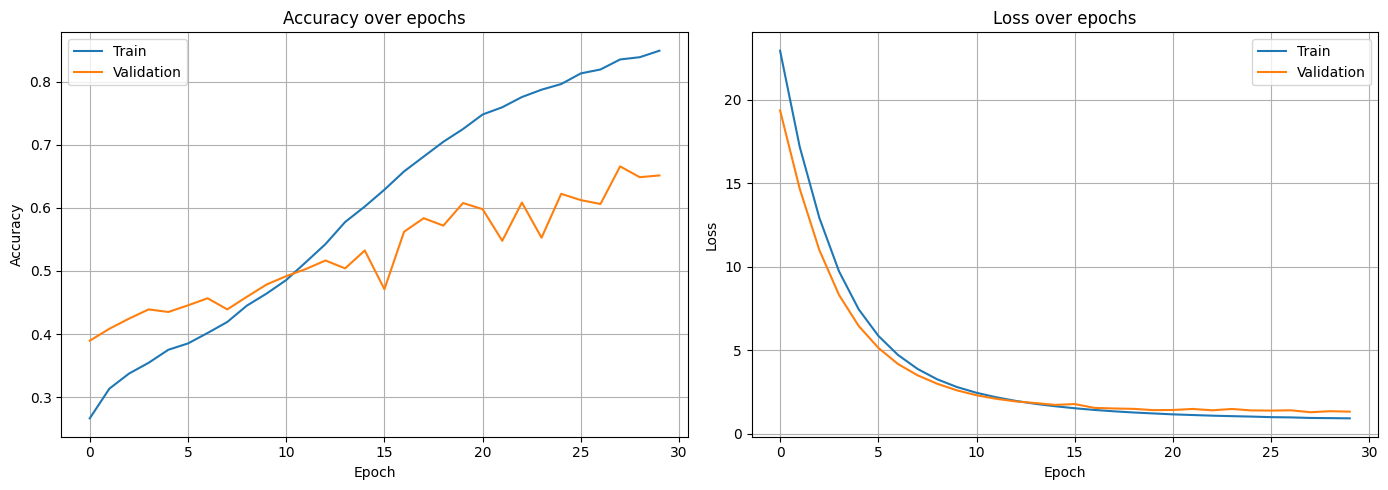

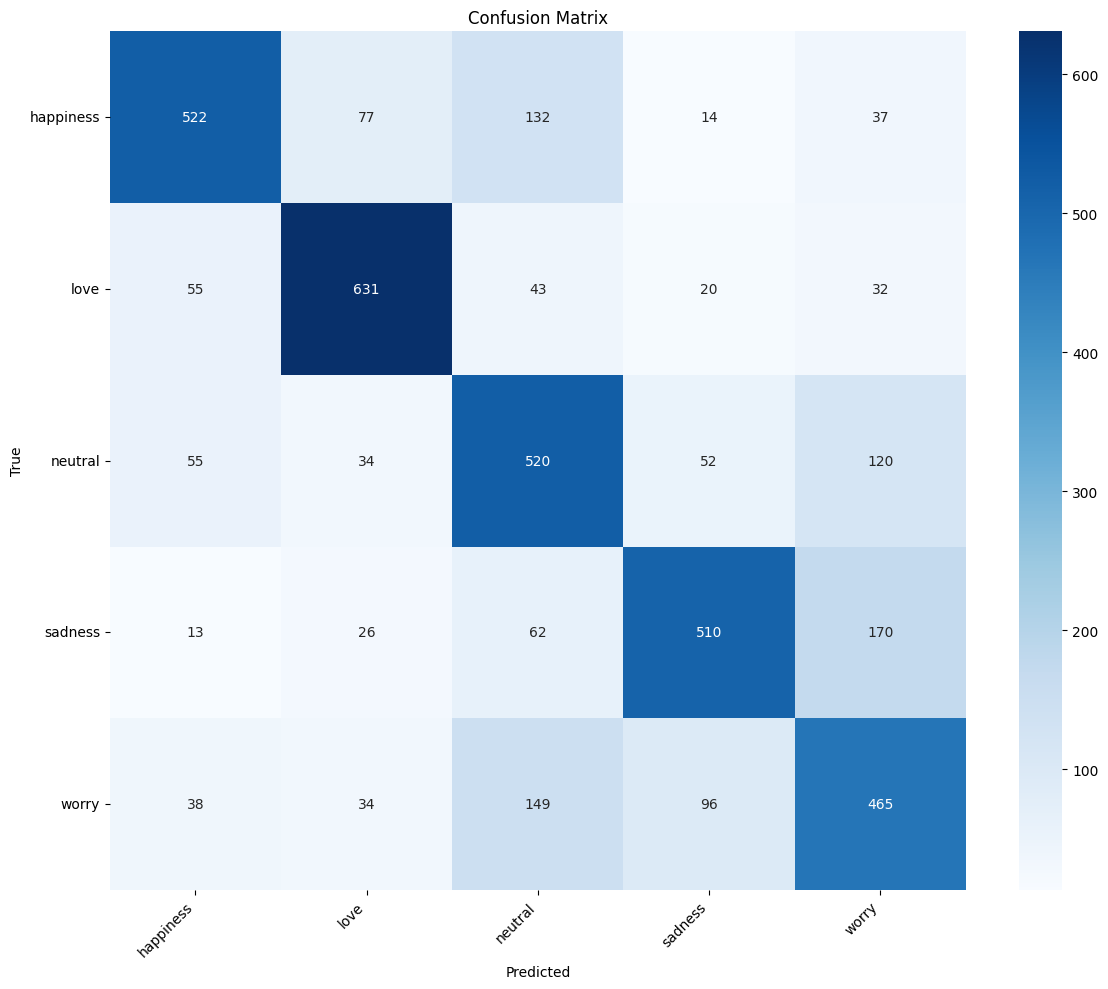

In [ ]:
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Ensure history (dictionary of metrics) is available for plotting
if 'history' not in globals():
    print("⚠️ 'history' variable not found in current session. Attempting to load from file...")
    try:
        # Define drive_path as it's needed for loading (consistent with previous cells)
        drive_path = '/content/drive/MyDrive/projet_integration/emotion_model/'
        history_file_path = os.path.join(drive_path, 'training_history.pkl')

        if os.path.exists(history_file_path):
            with open(history_file_path, 'rb') as f:
                loaded_history = pickle.load(f)
            # The saved history is already the dictionary of metrics (history.history from training cell)
            history = loaded_history
            print(f"✅ History loaded from {history_file_path}")
        else:
            print(f"❌ Error: training_history.pkl not found at {history_file_path}")
            # Fallback to empty data to prevent further NameErrors, but plots will be empty
            history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
    except Exception as e:
        print(f"❌ Error loading history from file: {e}")
        history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
elif hasattr(history, 'history') and isinstance(history.history, dict):
    # If history is a Keras History object (from model.fit() still in scope), extract the dictionary
    history = history.history

# ========== VISUALISATIONS ==========
# 1. Courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Check if history actually contains data before plotting
if history and len(history.get('accuracy', [])) > 0:
    axes[0].plot(history['accuracy'], label='Train')
    axes[0].plot(history['val_accuracy'], label='Validation')
    axes[0].set_title('Accuracy over epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history['loss'], label='Train')
    axes[1].plot(history['val_loss'], label='Validation')
    axes[1].set_title('Loss over epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)
else:
    print("⚠️ No training history data available for plotting learning curves.")

plt.tight_layout()
plt.show()

# 2. Matrice de confusion
plt.figure(figsize=(12, 10))

# Ensure y_pred_classes and label_list are available for confusion matrix
# y_test is expected to be in kernel state as per notebook context
if 'y_pred_classes' not in globals() and 'y_pred_classes' not in locals():
    print("⚠️ 'y_pred_classes' not found. Please ensure the evaluation cell was run.")
    # Attempt to run prediction if model and x_test are available
    try:
        if 'model' in globals() and 'x_test' in globals():
            print("Attempting to re-run prediction for confusion matrix...")
            y_pred = model.predict({
                'input_ids': x_test['input_ids'],
                'attention_mask': x_test['attention_mask']
            }, verbose=0)
            y_pred_classes = np.argmax(y_pred, axis=1)
            print("✅ Prediction re-run successfully.")
        else:
            print("❌ Cannot re-run prediction: 'model' or 'x_test' not found.")
            # Fallback to dummy data to prevent error if prediction cannot be made
            y_pred_classes = [0] * len(y_test) if 'y_test' in globals() else [0, 1]
            y_test = [0] * len(y_test) if 'y_test' in globals() else [0, 1]
    except Exception as e:
        print(f"❌ Error during prediction re-run: {e}")
        y_pred_classes = [0] * len(y_test) if 'y_test' in globals() else [0, 1]
        y_test = [0] * len(y_test) if 'y_test' in globals() else [0, 1]

if 'label_list' not in globals() and 'label_list' not in locals():
    print("⚠️ 'label_list' variable not found. Attempting to load from file...")
    try:
        drive_path = '/content/drive/MyDrive/projet_integration/emotion_model/'
        label_file_path = os.path.join(drive_path, 'label_mapping.pkl')
        if os.path.exists(label_file_path):
            with open(label_file_path, 'rb') as f:
                label_list = pickle.load(f)
            print(f"✅ label_list loaded from {label_file_path}")
        else:
            print(f"❌ Error: label_mapping.pkl not found at {label_file_path}")
            label_list = ['Unknown_0', 'Unknown_1', 'Unknown_2', 'Unknown_3', 'Unknown_4'] # Fallback
    except Exception as e:
        print(f"❌ Error loading label_list: {e}")
        label_list = ['Unknown_0', 'Unknown_1', 'Unknown_2', 'Unknown_3', 'Unknown_4'] # Fallback

# Ensure y_test and y_pred_classes are of comparable length for confusion matrix
if 'y_test' in globals() and 'y_pred_classes' in globals() and len(y_test) == len(y_pred_classes) and len(y_test) > 0:
    cm = confusion_matrix(y_test, y_pred_classes)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_list, yticklabels=label_list)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Cannot plot Confusion Matrix: y_test or y_pred_classes are not available or are empty/mismatched.")



In [ ]:
# ========== PRÉDICTION INTERACTIVE ==========
def predict_emotion(text):
    """Prédire l'émotion d'un texte"""
    cleaned = clean_text(text)
    encoded = tokenizer(
        cleaned, max_length=MAX_LEN,
        padding='max_length', truncation=True, return_tensors='tf'
    )

    prediction = model.predict({
        'input_ids': encoded['input_ids'],
        'attention_mask': encoded['attention_mask']
    }, verbose=0)[0]

    results = list(zip(label_list, prediction))
    results.sort(key=lambda x: x[1], reverse=True)

    print(f"\n📝 Texte: '{text}'")
    print(f"🧹 Nettoyé: '{cleaned}'")
    print(f"\n🎯 Prédictions:")
    for label, prob in results:
        bar = "█" * int(prob * 50)
        print(f"  {label:15s} {prob*100:5.2f}% {bar}")

    return results[0][0], results[0][1]

# Test avec votre exemple
print("\n" + "="*60)
print("TEST DU MODÈLE")
print("="*60)

test_texts = [
    "im so angry",
    "I love this so much!",
    "I'm feeling really sad today",
    "This is so boring",
    "Wow, what a surprise!",
]

for text in test_texts:
    emotion, confidence = predict_emotion(text)
    print()

# Mode interactif
print("\n" + "="*60)
while True:
    user_input = input("\n💬 Entrez un texte (ou 'quit' pour arrêter): ")
    if user_input.lower() in ['quit', 'exit', 'q']:
        break
    predict_emotion(user_input)


TEST DU MODÈLE

📝 Texte: 'im so angry'
🧹 Nettoyé: 'im so angry'

🎯 Prédictions:
  sadness         42.25% █████████████████████
  worry           41.95% ████████████████████
  neutral          5.43% ██
  love             5.25% ██
  happiness        5.12% ██


📝 Texte: 'I love this so much!'
🧹 Nettoyé: 'i love this so much'

🎯 Prédictions:
  love            80.28% ████████████████████████████████████████
  neutral          5.69% ██
  worry            5.66% ██
  happiness        4.93% ██
  sadness          3.44% █


📝 Texte: 'I'm feeling really sad today'
🧹 Nettoyé: 'i am feeling really sad today'

🎯 Prédictions:
  sadness         70.06% ███████████████████████████████████
  worry           17.62% ████████
  neutral          4.83% ██
  happiness        4.09% ██
  love             3.40% █


📝 Texte: 'This is so boring'
🧹 Nettoyé: 'this is so boring'

🎯 Prédictions:
  sadness         47.33% ███████████████████████
  worry           36.44% ██████████████████
  happiness        5.72% ██
  ne